In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [6]:
def get_weights_ffd(d, thres):
    '''
    Computing the weights for differentiating the series with fixed window size
    
        Parameters:
            d (float): differentiating factor
            thres (float): threshold for cutting off weights
    
        Returns:
            w (np.ndarray): array containing weights
    '''
    w, k = [1.0], 1
    while True:
        w_ = -w[-1] / k * (d - k + 1)
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    w = np.array(w[::-1]).reshape(-1, 1)
    return w

In [7]:
def frac_diff_ffd(series, d, thres=1e-5):
    '''
    Fractional differentiation with constant width window
    Note 1: thres determines the cut-off weight for the window
    Note 2: d can be any positive fractional, not necessarily bounded
    [0,1]
    
        Parameters:
            series (pd.DataFrame): dataframe with time series
            d (float): differentiating factor
            thres (float): threshold for cutting off weights
    
        Returns:
            df (pd.DataFrame): dataframe with differentiated series
    '''
    w = get_weights_ffd(d, thres)
    width = len(w) - 1
    
    df = {}
    for name in series.columns:
        series_f = series[[name]].ffill().dropna()
        df_ = pd.Series(index=np.arange(series.shape[0]), dtype=object)
        for iloc1 in range(width, series_f.shape[0]):
            loc0, loc1 = series_f.index[iloc1 - width], series_f.index[iloc1]
            if not np.isfinite(series.loc[loc1, name]):
                continue    # exclude NAs
            df_[loc1] = np.dot(w.T, series_f.loc[loc0:loc1])[0, 0]
        df[name] = df_.dropna().copy(deep=True)
    df = pd.concat(df, axis=1)
    return df

In [8]:
def ffd(process, thres=0.01):
    '''
    Finding the minimum differentiating factor that passes the ADF test
    
        Parameters:
            process (np.ndarray): array with random process values
            apply_constant_width (bool): flag that shows whether to use
             constant width window (if True) or increasing width window
             (if False)
            thres (float): threshold for cutting off weights
    '''
    for d in np.linspace(0, 1, 11):
        process_diff = frac_diff_ffd(pd.DataFrame(process), d, thres)
        test_results = adfuller(
            process_diff[process.name], maxlag=1, regression='c', autolag=None
        )
        if test_results[1] <= 0.05:
            break
    return process_diff[process.name]

In [9]:
# Generate sample non-stationary data
np.random.seed(42)
time_series = np.random.randn(100).cumsum()

In [10]:
# Perform ADF test
result = adfuller(time_series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')

ADF Statistic: -1.3583317659818996
p-value: 0.6020814791099096
Critical Values:
   1%, -3.498198082189098
Critical Values:
   5%, -2.891208211860468
Critical Values:
   10%, -2.5825959973472097


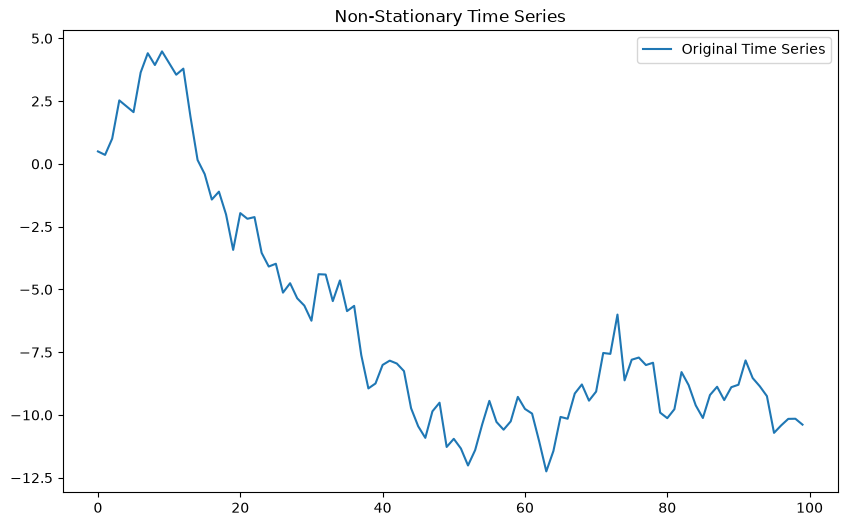

In [11]:
# Plot the time series
plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Original Time Series')
plt.title('Non-Stationary Time Series')
plt.legend()
plt.show()

In [35]:
# Differencing to make the series stationary
diff_series = ffd(pd.Series(time_series, name='time_series'),0.05)
    
# Perform ADF test on differenced series
result_diff = adfuller(diff_series)
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])
for key, value in result_diff[4].items():
    print('Critical Values (Differenced):')
    print(f'   {key}, {value}')

ADF Statistic (Differenced): -2.9967168293264277
p-value (Differenced): 0.03520214675177138
Critical Values (Differenced):
   1%, -3.503514579651927
Critical Values (Differenced):
   5%, -2.893507960466837
Critical Values (Differenced):
   10%, -2.583823615311909


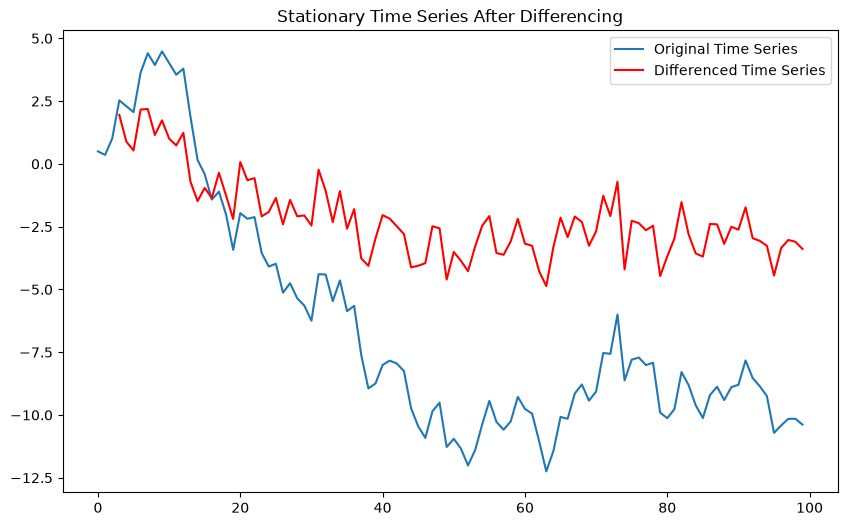

In [36]:
# Plot the differenced time series
plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Original Time Series')
plt.plot(diff_series, label='Differenced Time Series',color='red') 
plt.title('Stationary Time Series After Differencing')
plt.legend()
plt.show()